<a href="https://colab.research.google.com/github/Dokkae-bi/Intro-to-DL-Summer-26/blob/main/Final%20Project/Final_Project_image_captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Captioning — GRU Baseline (No Attention)
**ECGR 4106 Final Project — Anthony's half: data pipeline, encoder, training harness, baseline model**

This notebook is the end-to-end validation run for the project:
**ResNet-50 encoder (frozen) → mean-pooled features → GRU decoder (no attention)** on Flickr8k.

It also produces the shared infrastructure Aadit's four decoder variants will plug into:
- Cached spatial features (`[49, 2048]` per image) that attention decoders can attend over
- A vocabulary, Dataset/DataLoader, and training harness with fixed hyperparameters
- Batched greedy decoding + BLEU evaluation utilities

**Design decisions baked in (from earlier homework lessons):**
- Every cell is self-contained enough to survive *Restart and Run All*
- We checkpoint **both** the best-val-loss model *and* the best-val-BLEU model, because teacher-forced
  CE and free-running BLEU peak at different epochs (HW4 finding)
- All report numbers come from a final clean Restart-and-Run-All pass


## 1. Setup and configuration

One config dict rules everything. These hyperparameters must stay **identical across all five models**
so the comparison is fair — if you change anything here, tell Aadit.


In [1]:
import os, json, re, random, time, math
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

CFG = {
    "seed": 42,
    "data_dir": "/content/data",
    "min_word_freq": 5,     # words rarer than this in train captions become <unk>
    "emb_dim": 256,
    "hidden_dim": 512,
    "batch_size": 64,
    "lr": 3e-4,
    "max_epochs": 25,
    "patience": 4,          # early stop when NEITHER val loss NOR val BLEU-4 improves for this many epochs
    "grad_clip": 5.0,
    "max_decode_len": 30,   # cap for greedy generation
    "feature_dim": 2048,    # ResNet-50 final conv channels
    "num_pixels": 49,       # 7x7 spatial grid at 224x224 input
}

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
torch.cuda.manual_seed_all(CFG["seed"])
torch.backends.cudnn.benchmark = True  # speed > bit-exact determinism; expect small run-to-run jitter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## 2. Download Flickr8k (+ Karpathy splits)

- Images and caption text come from the widely-used Jason Brownlee GitHub mirror (original UIUC
  request form is defunct).
- We *try* to fetch the **Karpathy splits** (the standard 6,000 / 1,000 / 1,000 partition used in
  published captioning papers). If that server is down, we fall back to the official
  `Flickr_8k.trainImages.txt` split files, which are also 6k/1k/1k — just note in the report which
  one the final numbers used.

The images zip is ~1 GB, so this cell takes a few minutes the first time. `-nc` (no-clobber) makes
re-runs skip finished downloads.


In [2]:
os.makedirs(CFG["data_dir"], exist_ok=True)
%cd {CFG["data_dir"]}

!wget -nc -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -nc -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip -n -q Flickr8k_Dataset.zip
!unzip -n -q Flickr8k_text.zip

# Karpathy splits (best effort — fine if this server is down, we fall back below)
!wget -nc -q https://cs.stanford.edu/people/karpathy/deepimagesent/caption_datasets.zip || true
import zipfile
if os.path.exists("caption_datasets.zip") and not os.path.exists("dataset_flickr8k.json"):
    try:
        with zipfile.ZipFile("caption_datasets.zip") as z:
            z.extract("dataset_flickr8k.json")
    except zipfile.BadZipFile:
        print("Karpathy zip corrupted — using official Flickr8k split files instead.")

IMG_DIR = os.path.join(CFG["data_dir"], "Flicker8k_Dataset")  # yes, the zip really misspells "Flicker"
HAVE_KARPATHY = os.path.exists(os.path.join(CFG["data_dir"], "dataset_flickr8k.json"))
print("Images:", len(os.listdir(IMG_DIR)), "| Karpathy splits available:", HAVE_KARPATHY)


/content/data
Images: 8091 | Karpathy splits available: True


## 3. Parse captions and build splits

Output format (same for both split sources):

```
splits = {"train"|"val"|"test": [(filename, [ [token, ...] x5 ]), ...]}
```

Karpathy's JSON ships pre-tokenized captions; the fallback path tokenizes
`Flickr8k.token.txt` ourselves (lowercase, strip punctuation).


In [3]:
def tokenize(s):
    s = s.lower()
    s = re.sub(r"[^a-z ]+", " ", s)
    return s.split()

splits = {"train": [], "val": [], "test": []}

if HAVE_KARPATHY:
    with open(os.path.join(CFG["data_dir"], "dataset_flickr8k.json")) as f:
        kj = json.load(f)
    for img in kj["images"]:
        split = img["split"]
        if split == "restval":
            split = "train"
        caps = [s["tokens"] for s in img["sentences"]]
        splits[split].append((img["filename"], caps))
else:
    # captions: "1000268201_693b08cb0e.jpg#0	A child in a pink dress ..."
    caps_by_file = {}
    with open(os.path.join(CFG["data_dir"], "Flickr8k.token.txt")) as f:
        for line in f:
            if not line.strip():
                continue
            head, cap = line.split("\t")
            fname = head.split("#")[0]
            caps_by_file.setdefault(fname, []).append(tokenize(cap))
    split_files = {"train": "Flickr_8k.trainImages.txt",
                   "val":   "Flickr_8k.devImages.txt",
                   "test":  "Flickr_8k.testImages.txt"}
    for split, sf in split_files.items():
        with open(os.path.join(CFG["data_dir"], sf)) as f:
            for line in f:
                fname = line.strip()
                if fname and fname in caps_by_file:
                    splits[split].append((fname, caps_by_file[fname]))

for k, v in splits.items():
    print(f"{k}: {len(v)} images, {sum(len(c) for _, c in v)} captions")
print("Sample:", splits["train"][0][0], "→", " ".join(splits["train"][0][1][0]))


train: 6000 images, 30000 captions
val: 1000 images, 5000 captions
test: 1000 images, 5000 captions
Sample: 2513260012_03d33305cf.jpg → a black dog is running after a white dog in the snow


## 4. Vocabulary

Built from **training captions only** (no peeking at val/test). Words appearing fewer than
`min_word_freq` times map to `<unk>`. Special tokens: `<pad>=0`, `<start>`, `<end>`, `<unk>`.
Expect a vocab of roughly 2,500–3,000 words at min_freq=5.


In [4]:
PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"

counter = Counter()
for _, caps in splits["train"]:
    for c in caps:
        counter.update(c)

itos = [PAD, START, END, UNK] + sorted(w for w, n in counter.items() if n >= CFG["min_word_freq"])
stoi = {w: i for i, w in enumerate(itos)}
VOCAB_SIZE = len(itos)
PAD_IDX, START_IDX, END_IDX, UNK_IDX = (stoi[t] for t in (PAD, START, END, UNK))

def encode_caption(tokens):
    return [START_IDX] + [stoi.get(w, UNK_IDX) for w in tokens] + [END_IDX]

def decode_ids(ids):
    words = []
    for i in ids:
        if i == END_IDX:
            break
        if i not in (PAD_IDX, START_IDX):
            words.append(itos[i])
    return words

print(f"Vocab size: {VOCAB_SIZE} (from {len(counter)} unique train words)")
print("Round trip:", " ".join(decode_ids(encode_caption(splits['train'][0][1][0]))))


Vocab size: 2541 (from 7374 unique train words)
Round trip: a black dog is running after a white dog in the snow


## 5. Precompute ResNet-50 features (the encoder)

The encoder is **frozen** for the baseline, so we run every image through ResNet-50 exactly once and
cache the `7×7×2048` spatial grid to disk (fp16 → ~1.6 GB). This makes every subsequent training run
dramatically faster, and **Aadit's attention decoders read the same cache** — his models attend over
the 49 spatial positions; the baseline just mean-pools them.

Note for the report: at 224×224 input, ResNet-50's final conv stage yields a **7×7** grid (49
positions), not the 14×14 sometimes quoted for 448-px inputs — worth one sentence so the numbers
don't look inconsistent with the proposal.

Skips itself if the cache file already exists.


In [5]:
FEAT_PATH = os.path.join(CFG["data_dir"], "resnet50_feats_7x7_fp16.pt")

all_files = sorted({fname for split in splits.values() for fname, _ in split})
file_to_idx = {f: i for i, f in enumerate(all_files)}

if os.path.exists(FEAT_PATH):
    feats_all = torch.load(FEAT_PATH)
    print("Loaded cached features:", tuple(feats_all.shape))
else:
    weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
    resnet = torchvision.models.resnet50(weights=weights)
    encoder = nn.Sequential(*list(resnet.children())[:-2]).to(device).eval()  # drop avgpool+fc
    for p in encoder.parameters():
        p.requires_grad = False

    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    class ImageOnly(Dataset):
        def __len__(self): return len(all_files)
        def __getitem__(self, i):
            img = Image.open(os.path.join(IMG_DIR, all_files[i])).convert("RGB")
            return tfm(img)

    loader = DataLoader(ImageOnly(), batch_size=64, num_workers=2)
    feats_all = torch.empty(len(all_files), CFG["num_pixels"], CFG["feature_dim"], dtype=torch.float16)

    t0 = time.time()
    with torch.no_grad():
        for bi, imgs in enumerate(loader):
            f = encoder(imgs.to(device))                      # [B, 2048, 7, 7]
            f = f.flatten(2).transpose(1, 2)                  # [B, 49, 2048]
            feats_all[bi*64 : bi*64 + f.size(0)] = f.half().cpu()
            if bi % 20 == 0:
                print(f"  batch {bi}/{len(loader)}", end="\r")
    torch.save(feats_all, FEAT_PATH)
    del encoder
    torch.cuda.empty_cache()
    print(f"\nEncoded {len(all_files)} images in {time.time()-t0:.0f}s → {FEAT_PATH}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]



Encoded 8000 images in 69s → /content/data/resnet50_feats_7x7_fp16.pt


## 6. Dataset and DataLoaders

Training samples are **(image, caption) pairs** — 5 captions per image → ~30k train samples.
The collate function pads captions to the longest in the batch. For validation/test we also keep a
per-image loader (one entry per image, all 5 reference captions attached) for BLEU.


In [6]:
class CaptionDataset(Dataset):
    """One (image, caption) pair per item — used for teacher-forced training/val loss."""
    def __init__(self, split):
        self.items = [(file_to_idx[fname], encode_caption(c))
                      for fname, caps in splits[split] for c in caps]
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        fi, cap = self.items[i]
        return feats_all[fi].float(), torch.tensor(cap, dtype=torch.long)

def collate(batch):
    feats, caps = zip(*batch)
    lens = [len(c) for c in caps]
    padded = torch.full((len(caps), max(lens)), PAD_IDX, dtype=torch.long)
    for i, c in enumerate(caps):
        padded[i, :len(c)] = c
    return torch.stack(feats), padded

class ImageRefDataset(Dataset):
    """One image per item with all 5 reference token lists — used for BLEU decoding."""
    def __init__(self, split):
        self.entries = splits[split]
    def __len__(self):
        return len(self.entries)
    def __getitem__(self, i):
        fname, caps = self.entries[i]
        return feats_all[file_to_idx[fname]].float(), caps

def ref_collate(batch):
    feats, refs = zip(*batch)
    return torch.stack(feats), list(refs)

train_loader = DataLoader(CaptionDataset("train"), batch_size=CFG["batch_size"],
                          shuffle=True, collate_fn=collate, num_workers=2, drop_last=True)
val_loader   = DataLoader(CaptionDataset("val"), batch_size=CFG["batch_size"],
                          shuffle=False, collate_fn=collate, num_workers=2)
val_img_loader  = DataLoader(ImageRefDataset("val"),  batch_size=CFG["batch_size"],
                             shuffle=False, collate_fn=ref_collate)
test_img_loader = DataLoader(ImageRefDataset("test"), batch_size=CFG["batch_size"],
                             shuffle=False, collate_fn=ref_collate)

print(f"train pairs: {len(train_loader.dataset)}, val pairs: {len(val_loader.dataset)}")
print(f"val images: {len(val_img_loader.dataset)}, test images: {len(test_img_loader.dataset)}")


train pairs: 30000, val pairs: 5000
val images: 1000, test images: 1000


## 7. Baseline model — GRU decoder, no attention

The whole image is compressed into **one** vector (mean over the 49 spatial positions), which
initializes the GRU hidden state via a learned projection. After that, the decoder never looks at
the image again — this is exactly the bottleneck attention was invented to fix, which is what makes
it the right baseline.

Interface contract for Aadit's variants (so the harness below works unchanged):
- `forward(feats, caps) -> logits [B, T-1, V]` (teacher-forced; predicts caps[:,1:])
- `init_state(feats) -> state` and `step(state, tokens) -> (logits [B,V], state)` for decoding


In [7]:
class GRUBaseline(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, feature_dim, pad_idx):
        super().__init__()
        self.init_h = nn.Linear(feature_dim, hidden_dim)
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.drop = nn.Dropout(0.3)

    def _h0(self, feats):                      # feats: [B, 49, 2048]
        pooled = feats.mean(dim=1)             # [B, 2048]
        return torch.tanh(self.init_h(pooled)).unsqueeze(0)  # [1, B, H]

    def forward(self, feats, caps):
        h0 = self._h0(feats)
        emb = self.drop(self.emb(caps[:, :-1]))
        out, _ = self.gru(emb, h0)
        return self.fc(self.drop(out))         # [B, T-1, V]

    # --- decoding interface ---
    def init_state(self, feats):
        return self._h0(feats)
    def step(self, state, tokens):             # tokens: [B]
        emb = self.emb(tokens).unsqueeze(1)    # [B, 1, E]
        out, state = self.gru(emb, state)
        return self.fc(out.squeeze(1)), state  # [B, V], state

model = GRUBaseline(VOCAB_SIZE, CFG["emb_dim"], CFG["hidden_dim"],
                    CFG["feature_dim"], PAD_IDX).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params/1e6:.2f}M")


Trainable parameters: 4.19M


## 8. Harness: loss, batched greedy decoding, BLEU

- Loss: cross-entropy with `ignore_index=<pad>` so padding never contributes gradient.
- Greedy decoding is **batched** (whole batch steps together, finished sequences masked) so scoring
  1,000 val images per epoch stays cheap.
- BLEU-1..4 via NLTK `corpus_bleu` with smoothing (method1) against all 5 references per image.


In [8]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, total_tokens = 0.0, 0
    with torch.set_grad_enabled(training):
        for feats, caps in loader:
            feats, caps = feats.to(device), caps.to(device)
            logits = model(feats, caps)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), caps[:, 1:].reshape(-1))
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                optimizer.step()
            n_tok = (caps[:, 1:] != PAD_IDX).sum().item()
            total_loss += loss.item() * n_tok
            total_tokens += n_tok
    return total_loss / total_tokens

@torch.no_grad()
def greedy_decode_batch(model, feats, max_len):
    model.eval()
    B = feats.size(0)
    state = model.init_state(feats)
    tokens = torch.full((B,), START_IDX, dtype=torch.long, device=feats.device)
    done = torch.zeros(B, dtype=torch.bool, device=feats.device)
    outputs = []
    for _ in range(max_len):
        logits, state = model.step(state, tokens)
        tokens = logits.argmax(dim=-1)
        tokens = tokens.masked_fill(done, PAD_IDX)
        outputs.append(tokens)
        done |= tokens.eq(END_IDX)
        if done.all():
            break
    return torch.stack(outputs, dim=1)  # [B, <=max_len]

@torch.no_grad()
def evaluate_bleu(model, img_loader):
    hyps, refs = [], []
    for feats, ref_batch in img_loader:
        ids = greedy_decode_batch(model, feats.to(device), CFG["max_decode_len"])
        for row, r in zip(ids.cpu().tolist(), ref_batch):
            hyps.append(decode_ids(row))
            refs.append(r)
    sm = SmoothingFunction().method1
    weights = [(1,0,0,0), (0.5,0.5,0,0), (1/3,1/3,1/3,0), (0.25,0.25,0.25,0.25)]
    return [corpus_bleu(refs, hyps, weights=w, smoothing_function=sm) for w in weights]


## 9. Train

Every epoch we log train loss, **teacher-forced val loss**, and **free-running val BLEU-4** — and
checkpoint the best model under each criterion separately. Early stopping only fires when *neither*
has improved for `patience` epochs, so a late BLEU peak can't be cut off by an early CE optimum
(the HW4 lesson).

Rough expectation on a Colab T4: ~1–2 min/epoch including the val BLEU pass.


Epoch 01 | train 4.159 | val 3.461 (ppl 31.8) | val BLEU-4 0.1308 | 27s  *
Epoch 02 | train 3.292 | val 3.114 (ppl 22.5) | val BLEU-4 0.1633 | 25s  *
Epoch 03 | train 2.999 | val 2.955 (ppl 19.2) | val BLEU-4 0.1627 | 25s  *
Epoch 04 | train 2.819 | val 2.872 (ppl 17.7) | val BLEU-4 0.1763 | 25s  *
Epoch 05 | train 2.687 | val 2.807 (ppl 16.6) | val BLEU-4 0.1604 | 25s  *
Epoch 06 | train 2.582 | val 2.769 (ppl 15.9) | val BLEU-4 0.1778 | 24s  *
Epoch 07 | train 2.492 | val 2.744 (ppl 15.5) | val BLEU-4 0.1705 | 25s  *
Epoch 08 | train 2.414 | val 2.723 (ppl 15.2) | val BLEU-4 0.1812 | 25s  *
Epoch 09 | train 2.346 | val 2.715 (ppl 15.1) | val BLEU-4 0.1748 | 25s  *
Epoch 10 | train 2.282 | val 2.706 (ppl 15.0) | val BLEU-4 0.1871 | 25s  *
Epoch 11 | train 2.226 | val 2.705 (ppl 15.0) | val BLEU-4 0.1772 | 25s  *
Epoch 12 | train 2.173 | val 2.711 (ppl 15.0) | val BLEU-4 0.1802 | 25s
Epoch 13 | train 2.124 | val 2.709 (ppl 15.0) | val BLEU-4 0.1853 | 24s
Epoch 14 | train 2.076 | val 2.

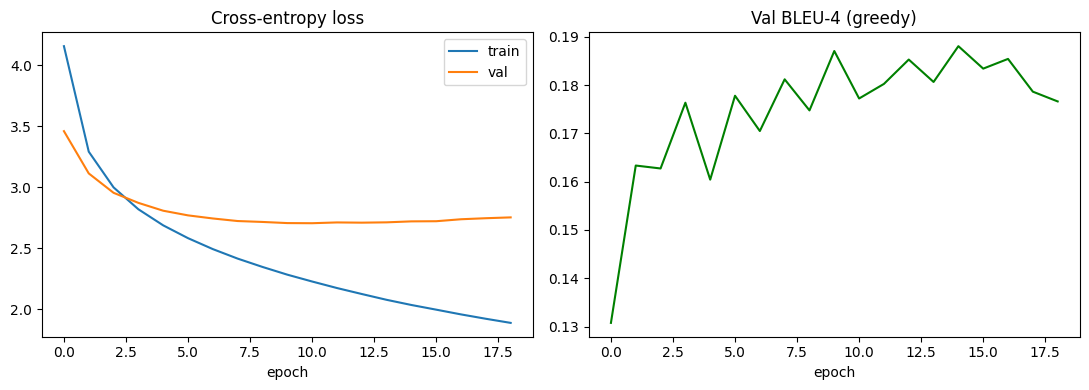

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])

history = {"train_loss": [], "val_loss": [], "val_bleu4": []}
best_val_loss, best_val_bleu = float("inf"), -1.0
epochs_since_improvement = 0

for epoch in range(1, CFG["max_epochs"] + 1):
    t0 = time.time()
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader)
    bleu = evaluate_bleu(model, val_img_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_bleu4"].append(bleu[3])

    improved = False
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_val_loss.pt")
        improved = True
    if bleu[3] > best_val_bleu:
        best_val_bleu = bleu[3]
        torch.save(model.state_dict(), "best_val_bleu.pt")
        improved = True
    epochs_since_improvement = 0 if improved else epochs_since_improvement + 1

    print(f"Epoch {epoch:02d} | train {train_loss:.3f} | val {val_loss:.3f} "
          f"(ppl {math.exp(val_loss):.1f}) | val BLEU-4 {bleu[3]:.4f} "
          f"| {time.time()-t0:.0f}s{'  *' if improved else ''}")

    if epochs_since_improvement >= CFG["patience"]:
        print(f"Early stopping: no improvement in loss or BLEU for {CFG['patience']} epochs.")
        break

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Cross-entropy loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["val_bleu4"], color="green")
ax[1].set_title("Val BLEU-4 (greedy)"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()


## 10. Test-set evaluation

Report numbers come from the **best-val-BLEU checkpoint** (that's the model-selection rule — state it
in the report). We print the best-val-loss checkpoint's scores too, since the gap between them *is*
the CE-vs-BLEU divergence story.


In [10]:
def report(tag, ckpt):
    model.load_state_dict(torch.load(ckpt, map_location=device))
    b = evaluate_bleu(model, test_img_loader)
    print(f"{tag:<22} BLEU-1 {b[0]:.4f} | BLEU-2 {b[1]:.4f} | BLEU-3 {b[2]:.4f} | BLEU-4 {b[3]:.4f}")
    return b

bleu_loss_ckpt = report("best-val-loss ckpt", "best_val_loss.pt")
bleu_bleu_ckpt = report("best-val-BLEU ckpt", "best_val_bleu.pt")


best-val-loss ckpt     BLEU-1 0.5944 | BLEU-2 0.4172 | BLEU-3 0.2818 | BLEU-4 0.1872
best-val-BLEU ckpt     BLEU-1 0.6076 | BLEU-2 0.4290 | BLEU-3 0.2926 | BLEU-4 0.1983


## 11. Qualitative check — generated captions on test images

Eyeball test: are captions grammatical and roughly on-topic? Baseline captions tend to be generic
("a dog runs through the grass" for most dog photos) — that genericness is *itself* a finding to
contrast against the attention models later. Re-run the cell for a different random sample.


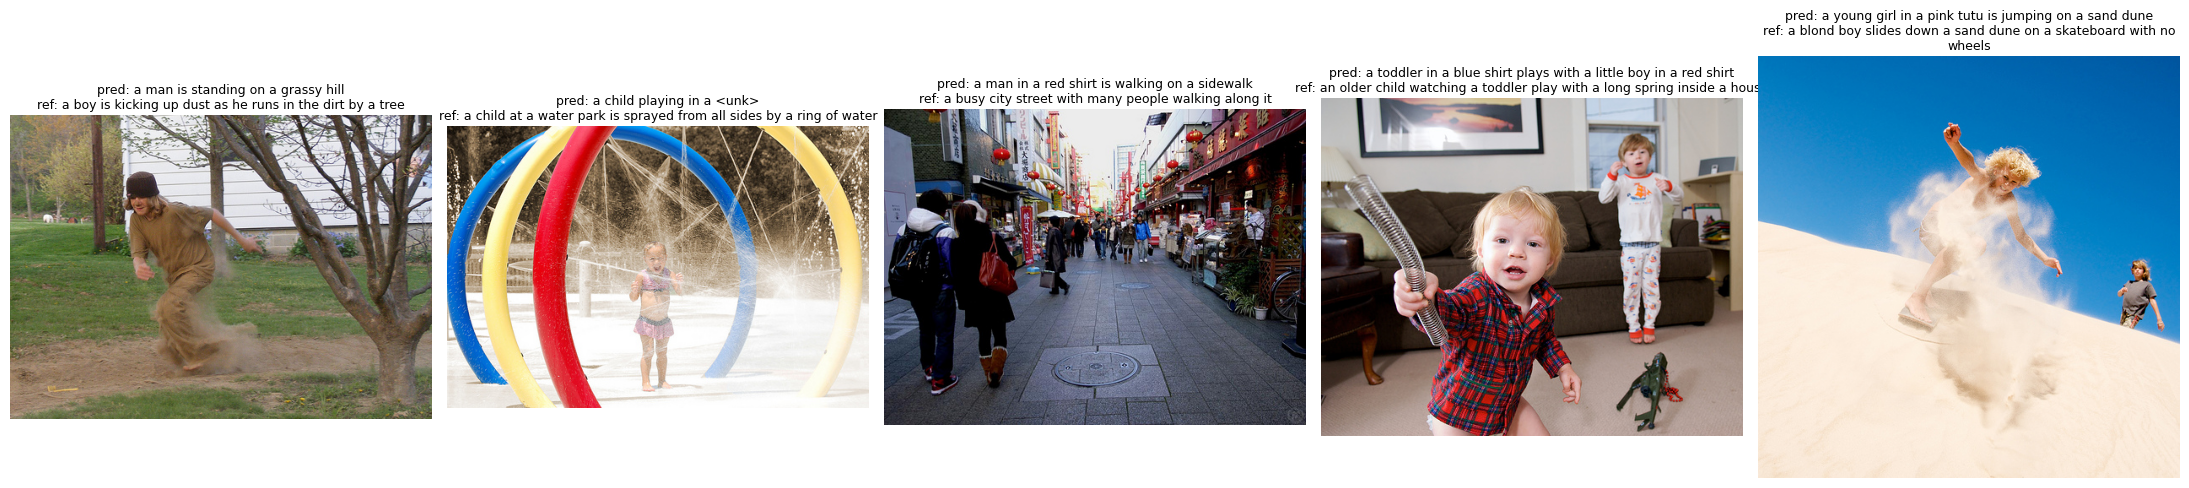

In [11]:
model.load_state_dict(torch.load("best_val_bleu.pt", map_location=device))
sample_idx = random.sample(range(len(splits["test"])), 5)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, i in zip(axes, sample_idx):
    fname, refs = splits["test"][i]
    feats = feats_all[file_to_idx[fname]].float().unsqueeze(0).to(device)
    ids = greedy_decode_batch(model, feats, CFG["max_decode_len"])[0].cpu().tolist()
    ax.imshow(Image.open(os.path.join(IMG_DIR, fname)).convert("RGB"))
    ax.axis("off")
    ax.set_title("pred: " + " ".join(decode_ids(ids)) + "\nref: " + " ".join(refs[0]),
                 fontsize=9, wrap=True)
plt.tight_layout(); plt.show()


## 12. Handoff notes for Aadit

Everything above this cell is shared infrastructure. To add a decoder variant:

1. **Implement the same interface** as `GRUBaseline`:
   - `forward(feats, caps) -> [B, T-1, V]` where `feats` is `[B, 49, 2048]` — attend over dim 1
   - `init_state(feats)` / `step(state, tokens)` for decoding (for attention models, keep `feats`
     inside the state tuple so `step` can attend each timestep; for the Transformer decoder,
     `step` can just re-run the growing prefix — sequences are ≤30 tokens, it's cheap)
2. **Do not touch `CFG`** — same lr, batch size, emb/hidden dims, patience for every model
3. Reuse `run_epoch`, `evaluate_bleu`, and the Cell 9 training loop as-is (just rename the
   checkpoint files per model, e.g. `luong_best_val_bleu.pt`)
4. The feature cache (`resnet50_feats_7x7_fp16.pt`) takes a few minutes to rebuild in a fresh
   Colab session — or copy it to Drive once and load from there

Beam search, METEOR/CIDEr, and attention heatmaps live on your side; the greedy/BLEU numbers here
are the common denominator every model reports.
